# 01 - Exploracion de Datos Historicos en Supabase

Este notebook conecta con Supabase para verificar los datos historicos del sensor BME680.

## 1. Instalacion de dependencias

In [1]:
import sys
!{sys.executable} -m pip install -q supabase pandas python-dotenv

## 2. Configuracion de conexion

In [2]:
from supabase import create_client
import pandas as pd
from dotenv import load_dotenv
import os

load_dotenv()

SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_KEY = os.getenv("SUPABASE_KEY")

supabase = create_client(SUPABASE_URL, SUPABASE_KEY)
print("Conexion a Supabase establecida")
print(f"URL: {SUPABASE_URL}")

Conexion a Supabase establecida
URL: https://ffwjdoguzaqpafuwaeam.supabase.co


## 3. Verificacion de estructura de tabla

In [3]:
response = supabase.table("grupo1_air_quality").select("*").limit(1).execute()

if response.data:
    print("Columnas disponibles:")
    for key in response.data[0].keys():
        print(f"  - {key}")
else:
    print("No se encontraron datos en la tabla")

Columnas disponibles:
  - id
  - estacion
  - temperatura
  - humedad
  - presion
  - altura
  - gas
  - iaq
  - eco2
  - voc
  - calidad_aire
  - created_at


## 4. Carga de datos historicos

In [4]:
response = supabase.table("grupo1_air_quality").select("*").order("created_at", desc=True).limit(100).execute()

df = pd.DataFrame(response.data)
print(f"Total registros cargados: {len(df)}")
df.head(10)

Total registros cargados: 100


,id,estacion,temperatura,humedad,presion,altura,gas,iaq,eco2,voc,calidad_aire,created_at
0,1128,grupo1,12.20359,33.21262,649.39,3598.568,48968,144.2235,1726.857,7.566954,Ligeramente contaminada,2026-06-15T11:44:21.451922-05:00
1,1127,grupo1,12.18014,34.17166,649.41,3598.330,49372,137.4507,1664.546,7.235084,Ligeramente contaminada,2026-06-15T11:42:21.244737-05:00
2,1126,grupo1,12.18901,32.38573,649.39,3598.568,50111,142.7627,1713.417,7.495370,Ligeramente contaminada,2026-06-15T11:41:21.28971-05:00
3,1125,grupo1,12.18014,32.47466,649.41,3598.330,50141,142.1712,1707.975,7.466389,Ligeramente contaminada,2026-06-15T11:40:21.208505-05:00
4,1124,grupo1,12.17221,31.27997,649.41,3598.330,50201,147.8509,1760.229,7.744695,Ligeramente contaminada,2026-06-15T11:39:21.314842-05:00
5,1123,grupo1,12.16873,30.27785,649.41,3598.330,50231,152.7147,1804.975,7.983018,Moderadamente contaminada,2026-06-15T11:38:21.185797-05:00
6,1122,grupo1,12.15478,29.47957,649.42,3598.210,49112,162.1839,1892.092,8.447009,Moderadamente contaminada,2026-06-15T11:37:21.436857-05:00
7,1121,grupo1,12.13481,29.35208,649.42,3598.210,48458,166.0229,1927.411,8.635121,Moderadamente contaminada,2026-06-15T11:36:21.239566-05:00
8,1120,grupo1,12.11485,28.96783,649.44,3597.971,47767,171.3268,1976.206,8.895012,Moderadamente contaminada,2026-06-15T11:35:21.327065-05:00
9,1119,grupo1,12.12245,28.72290,649.47,3597.614,47876,172.0179,1982.564,8.928875,Moderadamente contaminada,2026-06-15T11:34:21.281121-05:00


## 5. Estadisticas descriptivas

In [5]:
numeric_possible = ["temperatura", "humedad", "presion", "iaq", "eco2", "voc", "VOC", "gas", "altura"]
numeric_cols = [c for c in numeric_possible if c in df.columns]

print(f"Columnas numericas encontradas: {numeric_cols}")
if numeric_cols:
    df[numeric_cols].describe()
else:
    print("No se encontraron columnas numericas conocidas")

Columnas numericas encontradas: ['temperatura', 'humedad', 'presion', 'iaq', 'eco2', 'voc', 'gas', 'altura']


## 6. Distribucion de calidad del aire

In [6]:
if "calidad_aire" in df.columns:
    print("Distribucion de calidad_aire:")
    print(df["calidad_aire"].value_counts())
else:
    print("Columna calidad_aire no encontrada")

Distribucion de calidad_aire:
calidad_aire
Moderadamente contaminada    48
Altamente contaminada        47
Ligeramente contaminada       5
Name: count, dtype: int64


## 7. Rango temporal de los datos

In [7]:
if "created_at" in df.columns:
    df["created_at"] = pd.to_datetime(df["created_at"])
    print(f"Primer registro: {df['created_at'].min()}")
    print(f"Ultimo registro: {df['created_at'].max()}")
    print(f"Rango: {df['created_at'].max() - df['created_at'].min()}")

Primer registro: 2026-06-15 10:02:21.216258-05:00
Ultimo registro: 2026-06-15 11:44:21.451922-05:00
Rango: 0 days 01:42:00.235664


## 8. Visualizacion rapida de temperatura

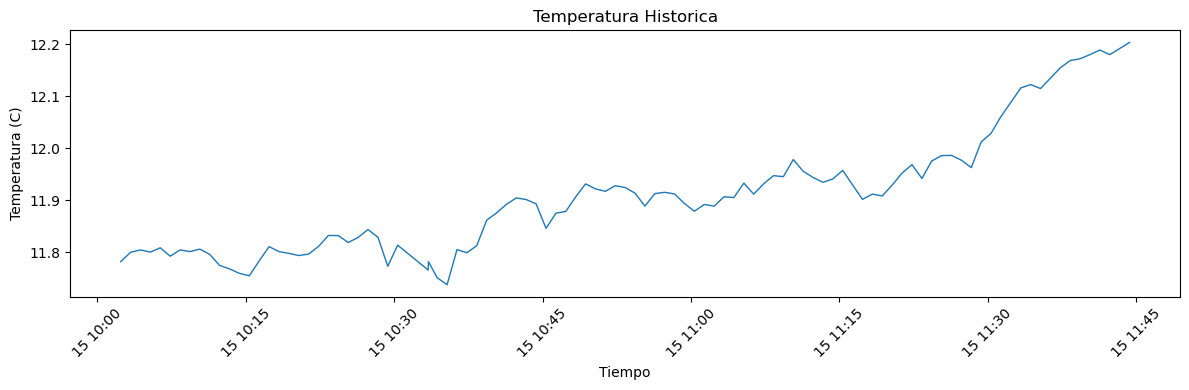

In [8]:
import matplotlib.pyplot as plt

if "created_at" in df.columns and "temperatura" in df.columns:
    df_sorted = df.sort_values("created_at")
    plt.figure(figsize=(12, 4))
    plt.plot(df_sorted["created_at"], df_sorted["temperatura"], linewidth=1)
    plt.title("Temperatura Historica")
    plt.xlabel("Tiempo")
    plt.ylabel("Temperatura (C)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 9. Dato mas reciente (polling opcional)

Esta celda hace polling a Supabase para ver el ultimo registro. No es streaming real, solo verificacion puntual.

In [9]:
import time

print("Obteniendo dato mas reciente cada 5 segundos (Ctrl+C para detener)...\n")
try:
    for i in range(6):
        resp = supabase.table("grupo1_air_quality").select("*").order("created_at", desc=True).limit(1).execute()
        if resp.data:
            d = resp.data[0]
            print(f"[{i+1}] {d.get('created_at')} | Temp: {d.get('temperatura')}C | Hum: {d.get('humedad')}% | IAQ: {d.get('iaq')}")
        time.sleep(5)
except KeyboardInterrupt:
    print("\nPolling detenido")

Obteniendo dato mas reciente cada 5 segundos (Ctrl+C para detener)...

[1] 2026-06-15T11:44:21.451922-05:00 | Temp: 12.20359C | Hum: 33.21262% | IAQ: 144.2235
[2] 2026-06-15T11:44:21.451922-05:00 | Temp: 12.20359C | Hum: 33.21262% | IAQ: 144.2235
[3] 2026-06-15T11:46:21.316124-05:00 | Temp: 12.25494C | Hum: 32.32383% | IAQ: 150.0627
[4] 2026-06-15T11:46:21.316124-05:00 | Temp: 12.25494C | Hum: 32.32383% | IAQ: 150.0627
[5] 2026-06-15T11:46:21.316124-05:00 | Temp: 12.25494C | Hum: 32.32383% | IAQ: 150.0627
[6] 2026-06-15T11:46:21.316124-05:00 | Temp: 12.25494C | Hum: 32.32383% | IAQ: 150.0627
